# FM Steel 3D Pipeline: Basic Walkthrough (Annotated)

Equivalent in scope to `fm_steel_3d_bas0.ipynb`, with two additions: a brief
statement of purpose preceding each stage, and terminology (PAG, KS variant,
pole figure, MDF) defined at first use. An optional `QUICK_DEMO` flag
(Part A) reduces the Monte Carlo domain size for faster execution during
initial review.

Related notebooks in this directory: `fm_steel_3d_bas0.ipynb` (unannotated
equivalent), `fm_steel_3d_int0.ipynb` (Transformations and PAG-technique
comparison enabled, deeper visualization), and `fm_steel_3d_adv0.ipynb`
(adds the Voronoi generation path and defaults Sub-block Generation to on).

**Pipeline stages**: base grain structure generation (Monte Carlo), cleaning
& topology repair, PAG clustering, block generation, KS orientation
assignment, visualization, raw data export, Abaqus mesh export, and ensemble
seed configuration.

FM Steel has no representativeness/EBSD-comparison capability today (unlike
the Twinned FCC pipeline) -- this notebook set has no equivalent stage.

## Part A: Start (Global Configuration)

This stage establishes the pipeline output directory and opens the report
session to which every subsequent stage appends its results.

The report session (`upxo.reporting.ReportSession`) accumulates outputs,
including raw exports, Abaqus mesh files, and the rendered report, under
`<output_dir>/FMSteel3D/...`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from upxo.pxtal.fm_steel_3d.steps import (
    steps_start, steps_base_grain_structure, steps_cleaning, steps_transformations,
    steps_pag_clustering, steps_block_generation, steps_subblock_generation,
    steps_visualization, steps_raw_export, steps_mesh_export, steps_ensemble,
)

In [2]:
RESEARCHER_NAME = ""
ORGANISATION = ""
EMAIL = ""
MATERIAL_NAME = "Low-alloy Steel"
PROCESSING_CONDITION = ""

report = steps_start.open_pipeline_report(
    researcher_name=RESEARCHER_NAME, organisation=ORGANISATION, email=EMAIL,
    material_name=MATERIAL_NAME, processing_condition=PROCESSING_CONDITION,
    notebook_tag='bas1')
report

### Quick-Demo Mode (Optional)

Setting `QUICK_DEMO = True` reduces the Monte Carlo domain size and step
count in Part B, substantially decreasing execution time for an initial
pass through the notebook. Results obtained under this setting are a
smaller, less statistically rich grain population than the full domain;
restore `QUICK_DEMO = False` (the default, matching the domain used in
`fm_steel_3d_bas0.ipynb`) for a fuller run.

In [3]:
QUICK_DEMO = False   # True = smaller/faster domain for a first read-through; False = full run matching bas0

## Part B: Base Grain Structure (Monte Carlo)

This stage produces the polycrystalline grain structure every later stage
builds on: PAGs (Part E) are clusters of these grains, blocks (Part F)
subdivide PAGs, and sub-blocks (if generated) subdivide blocks -- all of
it inherits its voxel geometry from here.

Method selection is unambiguous on this path: Monte Carlo is the base-grain-
structure generation method used in this notebook, distinct from the Voronoi
path covered in `fm_steel_3d_adv0.ipynb`. Executes a three-dimensional
Potts-model Monte Carlo grain-growth simulation, saving the grain-ID field
at intervals as it evolves -- each saved snapshot is a **temporal slice**.
One temporal slice (by default the most-annealed, i.e. largest-grained) is
then connected-component-labelled into the grain-ID field (`lgi`) used from
here on.

In [4]:
# NOTE: the full-size run (QUICK_DEMO=False, the default) can take a while --
# QUICK_DEMO=True trades grain-population richness for a much faster first pass.
NX, NY, NZ = (25, 25, 25) if QUICK_DEMO else (50, 50, 50)
Q_STATES = 10
MCSTEPS = 40 if QUICK_DEMO else 100
SAVE_INTERVAL = 5
RNG_SEED = 0

pxt = steps_base_grain_structure.run_mc_simulation(
    nx=NX, ny=NY, nz=NZ, q_states=Q_STATES, mcsteps=MCSTEPS, save_interval=SAVE_INTERVAL,
    mcalg='300b', consider_boltzmann=True, boltzmann_temp_factor=0.01, rng_seed=RNG_SEED)
tslices = list(pxt.m)
tslices

Algo_hops details
(('300b', 100),)
[False]


Initiating grain growth
----------------------------------------


GS temporal slice 0 stored


GS temporal slice 5 stored


GS temporal slice 10 stored


...

GS temporal slice 85 stored


GS temporal slice 90 stored


GS temporal slice 95 stored


|--------------- MC SIM RUN COMPLETED on: ALG310---------------|
Number of gs tslices: 20


[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]

In [5]:
CHOSEN_TSLICE = tslices[-1]   # most-annealed saved state
CONNECTIVITY = 6

lfi = steps_base_grain_structure.extract_mc_tslice_lfi(
    pxt, CHOSEN_TSLICE, connectivity=CONNECTIVITY, randomize_ids=True)
lfi.shape, len(np.unique(lfi))

((50, 50, 50), 123)

In [6]:
# Physical RVE dimensions (microns) -- isotropic voxels, LX/NX = voxel_size.
LX, LY, LZ = 50.0, 50.0, 50.0
VOXEL_SIZE = LX / NX

fm_base = steps_base_grain_structure.build_base(
    lfi, physical_dimensions=(LX, LY, LZ), voxel_size=VOXEL_SIZE, units='microns',
    connectivity=CONNECTIVITY, min_grain_nvoxels=-1, random_seed=RNG_SEED or 42)
fm_base.n_grains, fm_base.voxel_size

(123, 1.0)

## Part C: Cleaning & Topology Repair

Raw Monte Carlo connected-component labelling leaves behind tiny artefact
grains (voxel clusters far too small to be physically meaningful) and
occasional single-voxel "spikes" poking out of otherwise-solid grains.
This stage removes both, so PAG clustering next -- whose size targets are
specified in units of *grains* -- works from a physically sensible
population.

Dissolves grains smaller than a voxel threshold into their largest
neighbour, then removes single-voxel spike artefacts.

In [7]:
CLEAN_THRESHOLD = 8   # voxels

fm_base, clean_stats = steps_cleaning.clean(
    fm_base, threshold=CLEAN_THRESHOLD, max_passes=100, do_remove_spikes=True)
report.add_table([clean_stats], title='Post-Cleaning Grain Statistics', section='Cleaning')
clean_stats

{'n_grains': 92,
 'min_voxels': 7,
 'max_voxels': 10492,
 'mean_voxels': 1358.695652173913,
 'median_voxels': 418.0,
 'total_voxels': 125000,
 'domain_voxels': 125000}

## Part D: Transformations (Omitted)

An optional isotropic rescale/anisotropic stretch, and a separate "Sweep
Clean" resolution round-trip for conformal-meshing-ready smoothing, both
omitted in this basic walkthrough; the cleaned structure from Part C is used
unmodified. See `fm_steel_3d_int0.ipynb`/`fm_steel_3d_adv0.ipynb` to enable
this stage.

## Part E: PAG Clustering

This is the first martensite-specific stage: everything before it treats
the structure as generic polycrystalline grains, and everything after it
is described in terms of Prior Austenite Grains (PAGs) -- groups of grains
that clustered as a single austenite grain before quenching, whose own
sub-structure (blocks, sub-blocks) is what the rest of this pipeline builds.

Groups grains into PAGs via neighbour clustering (technique A), using a
single fixed lever; the multi-technique/lever comparison (PAG Technique
Advisor) is omitted here. A `pag_grain_fraction` knob controls how much of
the grain volume becomes martensite PAGs versus isolated "retained
austenite" PAGs (left at its full-martensite default of `1.0` here). Every
PAG is then assigned a random FCC (austenite) orientation.

In [8]:
PAG_SIZE_DISTRIBUTION = {'sizes': [3, 4, 5, 6], 'probs': [0.2, 0.35, 0.3, 0.15]}
PAG_LEVER = 'lever3'
PAG_GRAIN_FRACTION = 1.0   # fraction of grain volume retained as martensite PAGs;
                           # 1.0 - PAG_GRAIN_FRACTION becomes isolated "retained austenite"
                           # PAGs -- 1.0 (the default) means zero retained austenite
PAG_SEED = 42

fm_pag = steps_pag_clustering.generate_pags(
    fm_base, technique='A', pag_size_distribution=PAG_SIZE_DISTRIBUTION,
    lever=PAG_LEVER, pag_grain_fraction=PAG_GRAIN_FRACTION, random_seed=PAG_SEED)
print(f"n retained austenite PAGs: {len(fm_pag.retained_austenite_pag_ids)}")
len(fm_pag.clusters_dict)

n retained austenite PAGs: 0


29

In [9]:
steps_pag_clustering.assign_pag_orientations(fm_pag, pag_ori_mode='random', random_seed=PAG_SEED)
len(fm_pag.pag_orientations)

29

## Part F: Block Generation

Slices each PAG into martensitic **blocks** along its {111}FCC habit
planes -- thin, roughly parallel plates, each with its own orientation --
then assigns each block a Kurdjumov-Sachs (KS) variant: one of the 24
crystallographically equivalent orientation relationships by which
martensite can form from a given austenite orientation.

In [10]:
BLOCK_THICKNESS_RANGE = (2.0, 5.0)   # voxels
BLOCK_SEED = 42

fm_blk = steps_block_generation.generate_blocks(
    fm_pag, block_thickness_range=BLOCK_THICKNESS_RANGE, random_seed=BLOCK_SEED,
    block_slab_connectivity=26)
len(fm_blk.all_blocks)

470

In [11]:
fm_ori = steps_block_generation.assign_orientations(
    fm_blk, ks_variant_selection='random_per_block', random_seed=BLOCK_SEED)
len(fm_ori.block_orientations)

470

## Part G: Sub-block Generation

Sub-blocks further subdivide each block into thinner lamellae with a small
intra-block orientation spread, mimicking the fine internal structure real
martensitic blocks exhibit. Optional -- gated behind `GENERATE_SUBBLOCKS`
below (left `False` by default in this basic walkthrough; enabled by
default in `fm_steel_3d_adv0.ipynb`/`fm_steel_3d_adv1.ipynb`, the only tier
where this stage is exercised). When left off, `fm_sub` is `None` and Part
H's visualization suite simply skips the sub-block level.

In [12]:
GENERATE_SUBBLOCKS = False   # set True to also generate + visualize sub-blocks
SUBBLOCK_THICKNESS_RANGE_UM = (0.5, 1.5)
SUBBLOCK_SEED = 42

if GENERATE_SUBBLOCKS:
    fm_sub = steps_subblock_generation.generate_subblocks(
        fm_ori, subblock_thickness_range_um=SUBBLOCK_THICKNESS_RANGE_UM, random_seed=SUBBLOCK_SEED)
    print(f"{len(fm_sub.all_subblocks)} sub-blocks generated.")
else:
    fm_sub = None
    print("Sub-block generation skipped (GENERATE_SUBBLOCKS=False).")

Sub-block generation skipped (GENERATE_SUBBLOCKS=False).


## Part H: Visualization

A **pole figure** is a stereographic scatter of crystal-axis orientations;
a **misorientation distribution function (MDF)** is the histogram of
relative-rotation angles between neighbouring oriented features -- both
are computed per level below.

For each hierarchy level reached so far -- PAG, Packet, Block, and
Sub-block if `GENERATE_SUBBLOCKS` was set -- renders an interactive 3D
structure (colored per-feature with a colormap that stays distinguishable
even for hundreds of features; a fixed small palette like `tab20` makes
many features share an identical color once the count exceeds 20, which
is what made an earlier version of this cell render the *block* level as
a handful of indistinguishable blobs instead of the many thin martensitic
plates that are actually there), a scatter pole figure of that level's
orientations, a grid of seven 1st-order morphological properties (mean
volume, surface area, surface-area-to-volume ratio, aspect ratio,
junction-line segment length, triple-junction-point count, coordination
number), and its neighbour-pair (grain-boundary) misorientation
distribution. The 3D renders are interactive widgets embedded directly in
each cell's output (PyVista's `trame` backend), not static screenshots.

In [13]:
viz_stages = steps_raw_export.PipelineStages(
    fm_base=fm_base, fm_with_pags=fm_pag, fm_with_blocks=fm_blk,
    fm_with_orientations=fm_ori, fm_with_subblocks=fm_sub)

# Knobs for Part H's per-level visualization -- change these and re-run
# this cell (then re-run the visualize_level(...) calls below) to affect
# every level's viz output. Each has a matching keyword argument on
# visualize_level itself, so a single call can also override just one of
# these without touching the others.
VIZ_JUPYTER_BACKEND = 'trame'          # None for a separate blocking native window instead
RANDOMIZE_IDS = True                   # relabel feature IDs before rendering (matches the GUI's
                                        # own block_idx_map/block_fid_map convention) -- decorrelates
                                        # numerically-close labels from spatially-adjacent features,
                                        # BEFORE the colormap below ever sees them
ID_SEED = None                         # seed for the ID relabel shuffle; None = whatever numpy's
                                        # global random state already is (not reproducible run-to-run)
VIZ_CMAP = 'nipy_spectral'             # None = auto-build a distinguishable colormap (see VIZ_CMAP_SEED);
                                        # or pass any matplotlib colormap name/object to use directly
                                        # instead -- safe to use a plain sequential map like this one
                                        # once RANDOMIZE_IDS has already decorrelated the labels
VIZ_CMAP_SEED = 42                     # shuffle seed for the auto-built colormap; ignored if VIZ_CMAP is set
MORPHOLOGY_BINS = 20
MORPHOLOGY_FIGSIZE = (14, 7)
POLE_FAMILY = '100'
CRYSTAL_SYMMETRY = 'cubic'
APPLY_SAMPLE_SYMMETRIES = True
USE_RD, USE_TD, USE_ND = True, True, True
MISORIENTATION_N_BINS = 36
MISORIENTATION_ANGLE_RANGE = (0.0, 65.0)
MISORIENTATION_PLOT_BINS = None        # None = match MISORIENTATION_N_BINS


def visualize_level(
    level, fm, label,
    jupyter_backend=VIZ_JUPYTER_BACKEND, cmap=VIZ_CMAP, cmap_seed=VIZ_CMAP_SEED,
    randomize_ids=RANDOMIZE_IDS, id_seed=ID_SEED,
    morphology_bins=MORPHOLOGY_BINS, morphology_figsize=MORPHOLOGY_FIGSIZE,
    pole_family=POLE_FAMILY, crystal_symmetry=CRYSTAL_SYMMETRY,
    apply_sample_symmetries=APPLY_SAMPLE_SYMMETRIES, use_rd=USE_RD, use_td=USE_TD, use_nd=USE_ND,
    misorientation_n_bins=MISORIENTATION_N_BINS, misorientation_angle_range=MISORIENTATION_ANGLE_RANGE,
    misorientation_plot_bins=MISORIENTATION_PLOT_BINS,
):
    """3D render + pole figure + morphology grid + misorientation
    distribution for one hierarchy level, appending each plot to `report`.

    Every keyword argument here is a direct pass-through to the matching
    `steps_visualization` function -- see each one's own docstring
    (`render_3d`, `plot_morphology_grid`, `plot_pole_figure`,
    `misorientation_distribution`, `plot_misorientation_distribution`) for
    exactly what it controls. Defaults come from the module-level
    constants above; change those and re-run this cell to affect every
    `visualize_level(...)` call below, or pass a keyword argument directly
    to one call to override just that level.
    """
    print(f"--- {label} ---")

    # Interactive 3D render -- opens as an embedded, rotatable widget in
    # this cell's output (PyVista's trame backend by default).
    steps_visualization.render_3d(fm, level=level, jupyter_backend=jupyter_backend,
                                  cmap=cmap, cmap_seed=cmap_seed,
                                  randomize_ids=randomize_ids, id_seed=id_seed)

    coll = steps_visualization.distribution_stats(fm, level)
    aspect_ratios = steps_visualization.compute_aspect_ratios(fm, level)
    fig, _axes = steps_visualization.plot_morphology_grid(
        coll, aspect_ratios, bins=morphology_bins, figsize=morphology_figsize,
        suptitle=f'{label} Morphology')
    report.add_image(fig, title=f'{label} Morphology', section='Visualization')
    plt.show()

    orientations = steps_visualization.get_level_orientations(viz_stages, level)
    fig2, ax2 = steps_visualization.plot_pole_figure(
        orientations, pole_family=pole_family, crystal_symmetry=crystal_symmetry,
        apply_sample_symmetries=apply_sample_symmetries, use_rd=use_rd, use_td=use_td, use_nd=use_nd)
    ax2.set_title(f'{label} {{{pole_family}}} Pole Figure')
    report.add_image(fig2, title=f'{label} Pole Figure', section='Visualization')
    plt.show()

    mdf = steps_visualization.misorientation_distribution(
        orientations, coll, n_bins=misorientation_n_bins, angle_range=misorientation_angle_range)
    if mdf is not None:
        fig3, ax3 = plt.subplots(figsize=(6, 4))
        steps_visualization.plot_misorientation_distribution(
            mdf, ax=ax3, title=f'{label} Misorientation Distribution', bins=misorientation_plot_bins)
        report.add_image(fig3, title=f'{label} Misorientation Distribution', section='Visualization')
        plt.show()
    else:
        print("Not enough adjacent oriented features for a misorientation distribution.")

--- PAG ---


Widget(value='<iframe src="http://localhost:51649/index.html?ui=P_0x1e23174e270_0&reconnect=auto" class="pyvis…

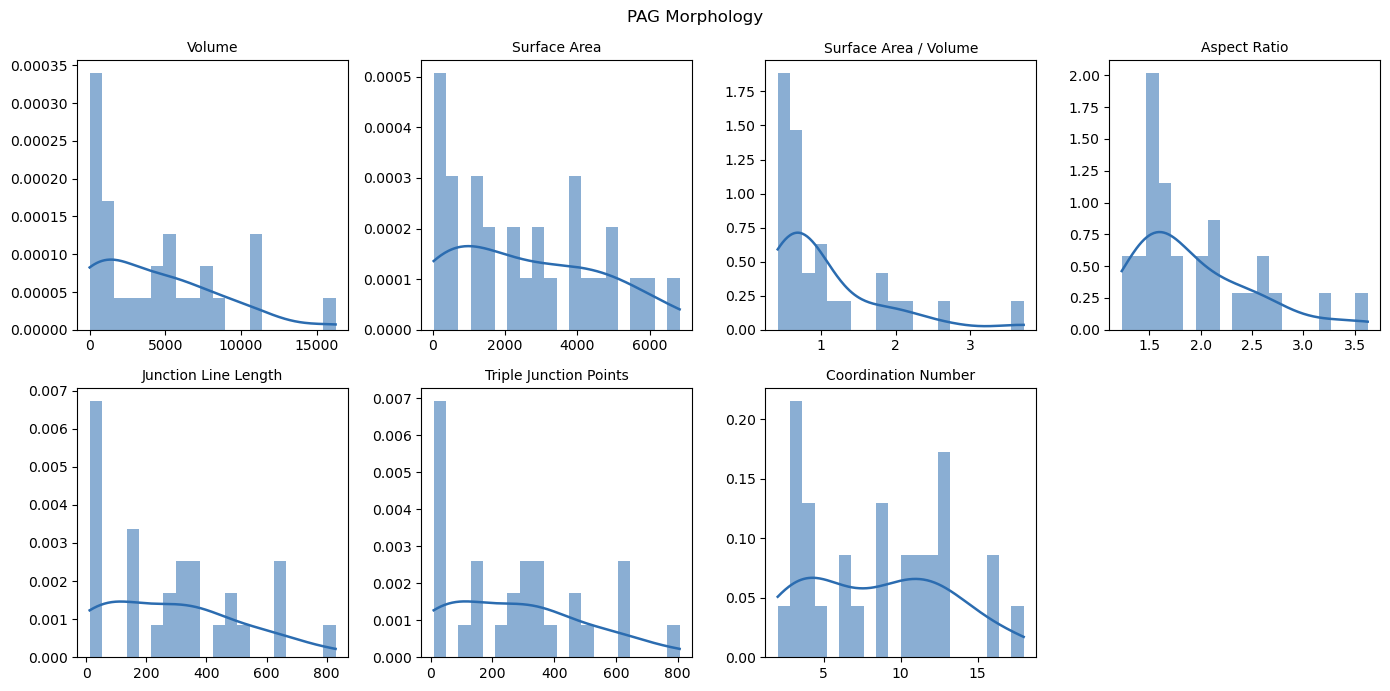

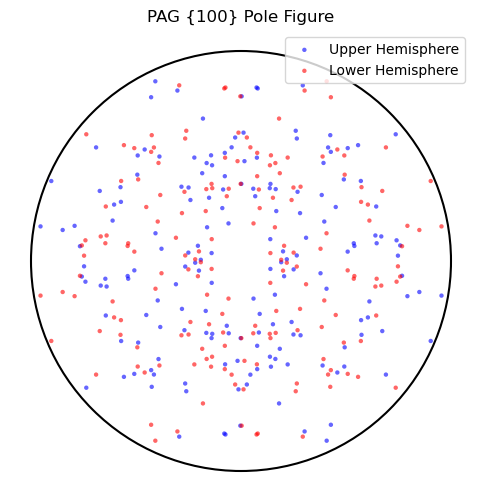

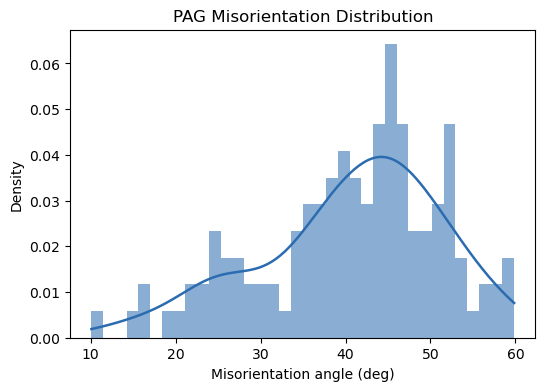

In [14]:
visualize_level(
    'pag', fm_pag, 'PAG',
    jupyter_backend=VIZ_JUPYTER_BACKEND, cmap=VIZ_CMAP, cmap_seed=VIZ_CMAP_SEED,
    randomize_ids=RANDOMIZE_IDS, id_seed=ID_SEED,
    morphology_bins=MORPHOLOGY_BINS, morphology_figsize=MORPHOLOGY_FIGSIZE,
    pole_family=POLE_FAMILY, crystal_symmetry=CRYSTAL_SYMMETRY,
    apply_sample_symmetries=APPLY_SAMPLE_SYMMETRIES, use_rd=USE_RD, use_td=USE_TD, use_nd=USE_ND,
    misorientation_n_bins=MISORIENTATION_N_BINS, misorientation_angle_range=MISORIENTATION_ANGLE_RANGE,
    misorientation_plot_bins=MISORIENTATION_PLOT_BINS,
)

--- Packet ---


Widget(value='<iframe src="http://localhost:51649/index.html?ui=P_0x1e23163d090_0&reconnect=auto" class="pyvis…

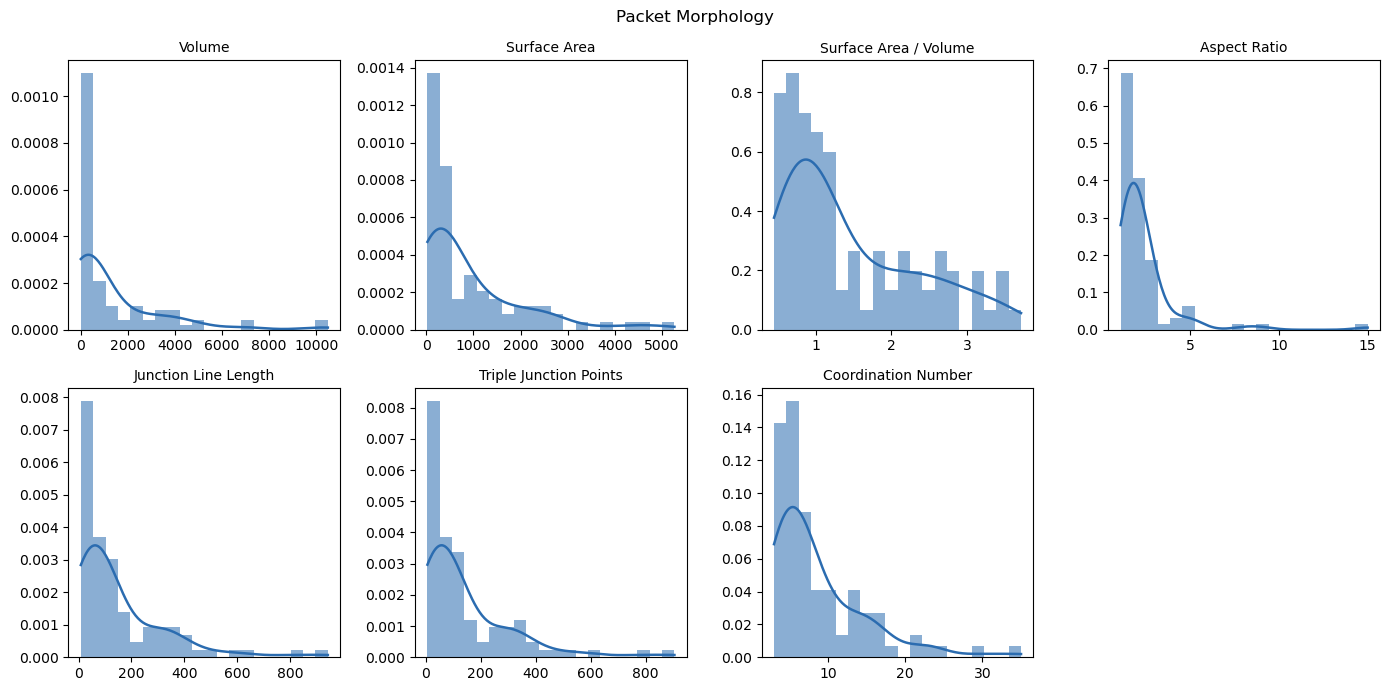

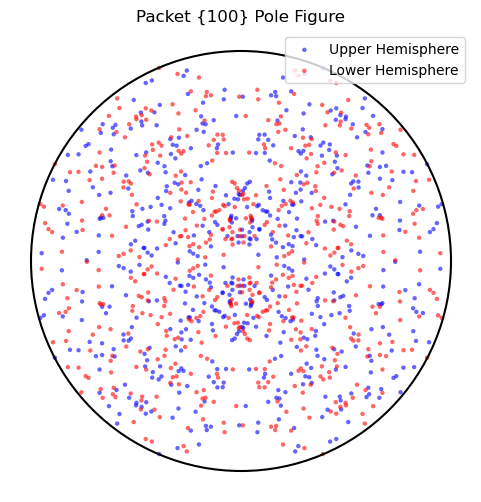

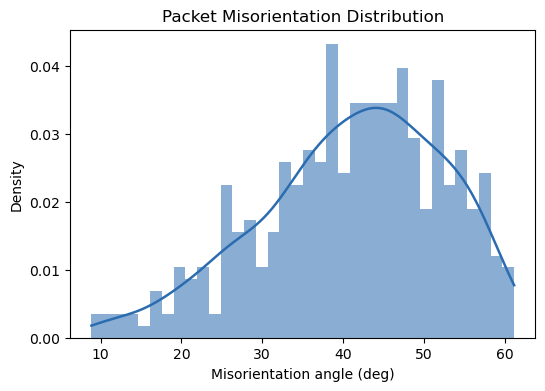

In [15]:
visualize_level(
    'packet', fm_blk, 'Packet',
    jupyter_backend=VIZ_JUPYTER_BACKEND, cmap=VIZ_CMAP, cmap_seed=VIZ_CMAP_SEED,
    randomize_ids=RANDOMIZE_IDS, id_seed=ID_SEED,
    morphology_bins=MORPHOLOGY_BINS, morphology_figsize=MORPHOLOGY_FIGSIZE,
    pole_family=POLE_FAMILY, crystal_symmetry=CRYSTAL_SYMMETRY,
    apply_sample_symmetries=APPLY_SAMPLE_SYMMETRIES, use_rd=USE_RD, use_td=USE_TD, use_nd=USE_ND,
    misorientation_n_bins=MISORIENTATION_N_BINS, misorientation_angle_range=MISORIENTATION_ANGLE_RANGE,
    misorientation_plot_bins=MISORIENTATION_PLOT_BINS,
)

--- Block ---


Widget(value='<iframe src="http://localhost:51649/index.html?ui=P_0x1e2469af390_0&reconnect=auto" class="pyvis…

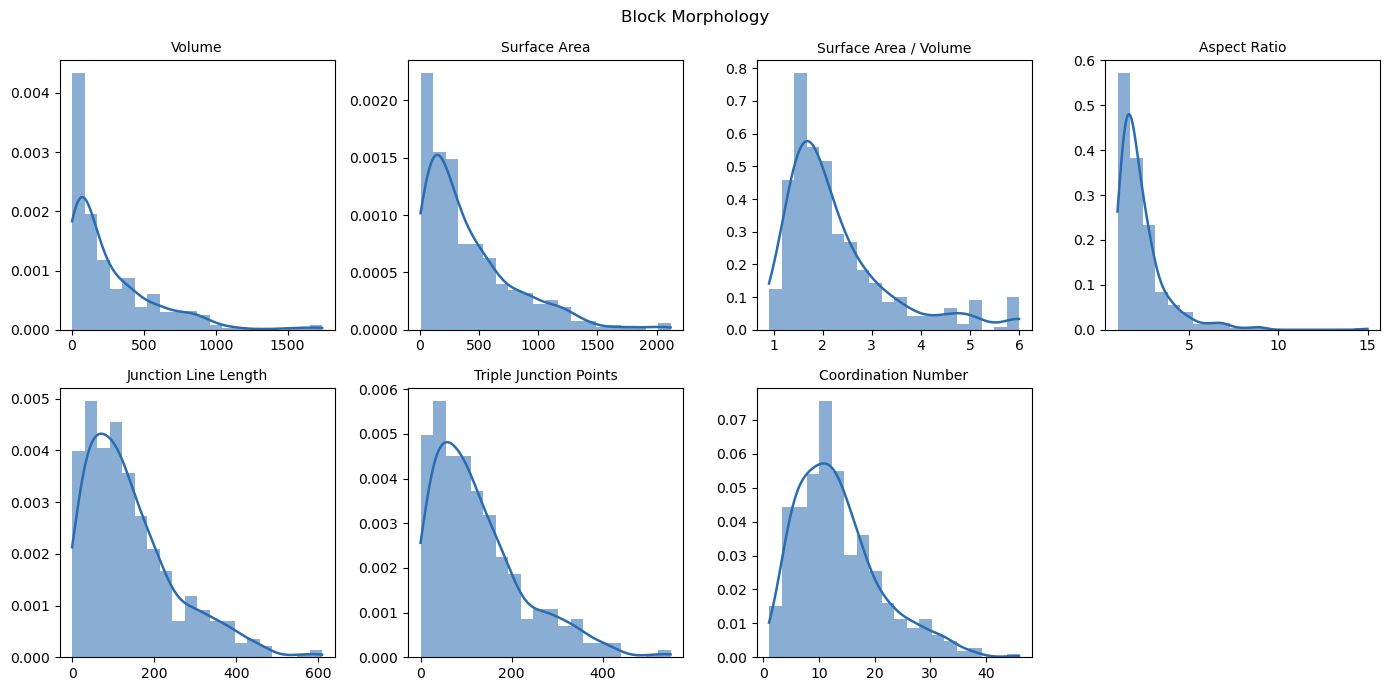

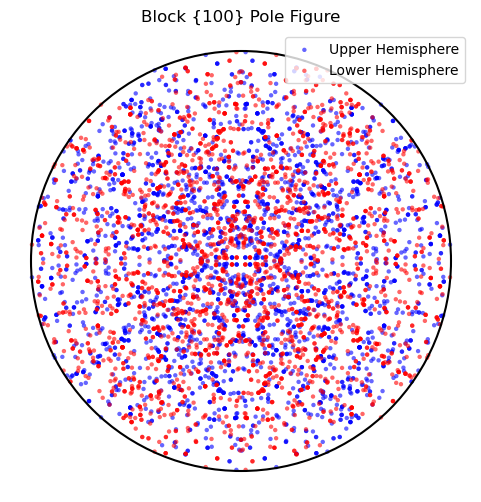

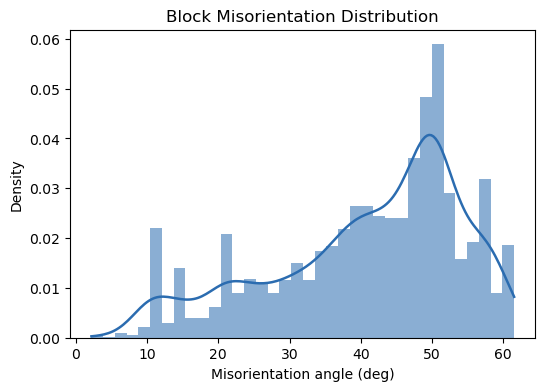

In [16]:
visualize_level(
    'block', fm_ori, 'Block',
    jupyter_backend=VIZ_JUPYTER_BACKEND, cmap=VIZ_CMAP, cmap_seed=VIZ_CMAP_SEED,
    randomize_ids=RANDOMIZE_IDS, id_seed=ID_SEED,
    morphology_bins=MORPHOLOGY_BINS, morphology_figsize=MORPHOLOGY_FIGSIZE,
    pole_family=POLE_FAMILY, crystal_symmetry=CRYSTAL_SYMMETRY,
    apply_sample_symmetries=APPLY_SAMPLE_SYMMETRIES, use_rd=USE_RD, use_td=USE_TD, use_nd=USE_ND,
    misorientation_n_bins=MISORIENTATION_N_BINS, misorientation_angle_range=MISORIENTATION_ANGLE_RANGE,
    misorientation_plot_bins=MISORIENTATION_PLOT_BINS,
)

In [17]:
if GENERATE_SUBBLOCKS:
    visualize_level(
        'subblock', fm_sub, 'Sub-block',
        jupyter_backend=VIZ_JUPYTER_BACKEND, cmap=VIZ_CMAP, cmap_seed=VIZ_CMAP_SEED,
        randomize_ids=RANDOMIZE_IDS, id_seed=ID_SEED,
        morphology_bins=MORPHOLOGY_BINS, morphology_figsize=MORPHOLOGY_FIGSIZE,
        pole_family=POLE_FAMILY, crystal_symmetry=CRYSTAL_SYMMETRY,
        apply_sample_symmetries=APPLY_SAMPLE_SYMMETRIES, use_rd=USE_RD, use_td=USE_TD, use_nd=USE_ND,
        misorientation_n_bins=MISORIENTATION_N_BINS, misorientation_angle_range=MISORIENTATION_ANGLE_RANGE,
        misorientation_plot_bins=MISORIENTATION_PLOT_BINS,
    )
else:
    print("Sub-block visualization skipped (GENERATE_SUBBLOCKS=False).")

Sub-block visualization skipped (GENERATE_SUBBLOCKS=False).


### Exploded Views

`render_3d` above only ever shows whichever features happen to be exposed on
the domain's outer shell -- most blocks/sub-blocks don't reach it and are
simply invisible in that render, regardless of colormap. This mirrors the
GUI's own "BLK/SBLK Exploded View" (Visualization Settings page, windows
W11/W12): every block is rigidly translated away from its own parent PAG's
centroid (sub-blocks away from their own parent block's centroid) by
`explosion_factor` -- `0` reproduces the true, unexploded layout exactly, as
a sanity check; anything higher pulls features apart so ones that were
buried inside a solid PAG/block become visible from outside.

In [18]:
EXPLOSION_FACTOR_BLOCK = 0.6
EXPLOSION_FACTOR_SUBBLOCK = 0.4

n_exploded_blocks = steps_visualization.render_3d_exploded(
    viz_stages, level='block', explosion_factor=EXPLOSION_FACTOR_BLOCK,
    jupyter_backend=VIZ_JUPYTER_BACKEND, cmap=VIZ_CMAP, cmap_seed=VIZ_CMAP_SEED,
    randomize_ids=RANDOMIZE_IDS, id_seed=ID_SEED,
)
print(f"Exploded {n_exploded_blocks} block(s).")

Widget(value='<iframe src="http://localhost:51649/index.html?ui=P_0x1e24836f610_0&reconnect=auto" class="pyvis…

Exploded 470 block(s).


In [19]:
if GENERATE_SUBBLOCKS:
    n_exploded_subblocks = steps_visualization.render_3d_exploded(
        viz_stages, level='subblock', explosion_factor=EXPLOSION_FACTOR_SUBBLOCK,
        jupyter_backend=VIZ_JUPYTER_BACKEND, cmap=VIZ_CMAP, cmap_seed=VIZ_CMAP_SEED,
        randomize_ids=RANDOMIZE_IDS, id_seed=ID_SEED,
    )
    print(f"Exploded {n_exploded_subblocks} sub-block(s).")
else:
    print("Exploded sub-block view skipped (GENERATE_SUBBLOCKS=False).")

Exploded sub-block view skipped (GENERATE_SUBBLOCKS=False).


## Part I: Raw Data Exports

Writes the base grain structure's raw arrays and metadata (`.npy`/`.pkl`) --
the artifacts an external tool (a stats script, a different mesher) would
read to pick up the pipeline from this point without re-running it. Only
the base level is exported here; PAG/Block level exports are added in
`fm_steel_3d_int0.ipynb`, and the full 5-level export (incl. Sub-block) in
`fm_steel_3d_adv0.ipynb`.

In [20]:
stages = steps_raw_export.PipelineStages(fm_base=fm_base)   # base level only
raw_result = steps_raw_export.export_raw(
    stages, out_dir=steps_start.DEFAULT_OUTPUT_DIR / 'FMSteel3D' / 'RawExports' / 'bas1',
    formats=('npy', 'pkl'), levels=[])
raw_result

{'out_dir': 'C:\\Development\\UPXO\\upxo_library\\data\\FMSteel3D\\RawExports\\bas1',
 'files': {'base_lgi.npy': 500128, 'raw_export.pkl': 3506315},
 'n_entries': 9,
 'levels_exported': [],
 'levels_skipped': {}}

## Part J: Mesh Export

Exports a full Abaqus voxel-conformal mesh (`.inp` files) of the block-level
structure as linear hexahedral (C3D8) elements, with element sets by PAG/
packet/block and node sets on each domain face (default naming prefixes).
This is the pipeline's terminal artifact -- a mesh a solver can consume
directly (once boundary conditions/steps are added; see the warnings
printed below).

In [21]:
mesh_dir = steps_start.DEFAULT_OUTPUT_DIR / 'FMSteel3D' / 'ABQInputFiles'
mesh_path = steps_mesh_export.export_mesh(
    fm_ori, mesh_dir, folder_name='fm_steel_3d_bas1_mesh', element_type='C3D8',
    output_unit='microns')
report.add_table([{'output_dir': str(mesh_path)}], title='Abaqus Mesh Export', section='Mesh Export')
mesh_path

Output directory created: C:\Development\UPXO\upxo_library\data\FMSteel3D\ABQInputFiles\fm_steel_3d_bas1_mesh1


C3D8 mesh written: C:\Development\UPXO\upxo_library\data\FMSteel3D\ABQInputFiles\fm_steel_3d_bas1_mesh1


C:\Development\UPXO\upxo_library\src\upxo\pxtal\fm_steel_3d\mesh_exporter_3d.py:1649: UserWarning: 07_interactions.inp contains no interaction/constraint definitions (periodic BCs, tie constraints, contact) -- this .inp is not simulation-ready as exported and must be edited before submission.
  out_dir = self._export_core(fm_state, folder_name, 'C3D8',
C:\Development\UPXO\upxo_library\src\upxo\pxtal\fm_steel_3d\mesh_exporter_3d.py:1649: UserWarning: 08_steps_output.inp contains no *Step/boundary-condition/*Output definitions -- this .inp is not simulation-ready as exported and must be edited before submission.
  out_dir = self._export_core(fm_state, folder_name, 'C3D8',


WindowsPath('C:/Development/UPXO/upxo_library/data/FMSteel3D/ABQInputFiles/fm_steel_3d_bas1_mesh1')

## Part K: Ensemble Seed Config

Snapshots this run's parameters to a JSON "seed" file, for a future ensemble
generator to consume (FM Steel has no ensemble generator today -- this is a
parameter-capture pedestal, matching the GUI's own Ensemble Seed Config page).

In [22]:
run_params = {
    'QUICK_DEMO': QUICK_DEMO,
    'NX': NX, 'NY': NY, 'NZ': NZ, 'LX': LX, 'LY': LY, 'LZ': LZ, 'VOXEL_SIZE': VOXEL_SIZE,
    'Q_STATES': Q_STATES, 'MCSTEPS': MCSTEPS, 'SAVE_INTERVAL': SAVE_INTERVAL,
    'RNG_SEED': RNG_SEED, 'CHOSEN_TSLICE': CHOSEN_TSLICE, 'CONNECTIVITY': CONNECTIVITY,
    'CLEAN_THRESHOLD': CLEAN_THRESHOLD,
    'PAG_SIZE_DISTRIBUTION': PAG_SIZE_DISTRIBUTION, 'PAG_LEVER': PAG_LEVER,
    'PAG_GRAIN_FRACTION': PAG_GRAIN_FRACTION, 'PAG_SEED': PAG_SEED,
    'BLOCK_THICKNESS_RANGE': BLOCK_THICKNESS_RANGE, 'BLOCK_SEED': BLOCK_SEED,
}

ensemble_dir = steps_start.DEFAULT_OUTPUT_DIR / 'FMSteel3D' / 'EnsembleConfigs'
seed_path = steps_ensemble.write_seed_config(
    run_params, ensemble_dir, seed_name='fm_steel_3d_bas1', pipeline_mode='block')
seed_path

WindowsPath('C:/Development/UPXO/upxo_library/data/FMSteel3D/EnsembleConfigs/fm_steel_3d_bas1_0.json')

## Finish: Report Generation

Renders the accumulated `add_table`/`add_image` entries into a single
`report.html` file.

In [23]:
report_path = steps_start.finish_report(report)
print('Report written to:', report_path)

Report written to: C:\Development\UPXO\upxo_library\data\FMSteel3D\Reports\bas1\report.html
